# Feature Engineering & Data Preparation

This notebook:
1. Loads daily aggregated energy data
2. Calculates daily wastage (target variable)
3. Creates lag and rolling average features
4. Adds time-based features
5. Loads and merges weather data (Colombo, Galle, Matara)
6. Prepares final dataset for ML models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 1. Load Daily Energy Data

In [2]:
# Load the daily energy CSV created in previous notebook
data_path = Path('../data/processed/daily_energy.csv')
df = pd.read_csv(data_path)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nHouseholds: {df['household'].unique()}")
print(f"\nFirst few rows:")
print(df.head(10))

Dataset shape: (6412, 4)

Date range: 2014-12-11 00:00:00 to 2019-05-01 00:00:00

Households: ['residential1' 'residential3' 'residential4' 'residential6']

First few rows:
        date  daily_pv_kwh  daily_load_kwh     household
0 2014-12-11           0.0             0.0  residential1
1 2014-12-12           0.0             0.0  residential1
2 2014-12-13           0.0             0.0  residential1
3 2014-12-14           0.0             0.0  residential1
4 2014-12-15           0.0             0.0  residential1
5 2014-12-16           0.0             0.0  residential1
6 2014-12-17           0.0             0.0  residential1
7 2014-12-18           0.0             0.0  residential1
8 2014-12-19           0.0             0.0  residential1
9 2014-12-20           0.0             0.0  residential1


## 2. Calculate Daily Wastage (Target Variable)

In [28]:
# Define export limit (realistic household limit)
# Assumption: Grid can accept up to 10 kWh/day from each household
EXPORT_LIMIT_KWH = 20  # kWh per day

# Calculate net energy available for export
df['net_export'] = df['daily_pv_kwh'] - df['daily_load_kwh']

# Calculate wasted energy (excess above export limit)
df['wasted_energy_kwh'] = (df['net_export'] - EXPORT_LIMIT_KWH).clip(lower=0)

print(f"Export Limit: {EXPORT_LIMIT_KWH} kWh/day")
print(f"\nWastage Statistics by Household:")
print(df.groupby('household')['wasted_energy_kwh'].describe().round(2))
print(f"\nOverall Wastage:")
print(f"  Days with wastage: {(df['wasted_energy_kwh'] > 0).sum()} / {len(df)}")
print(f"  Percentage of days: {(df['wasted_energy_kwh'] > 0).sum() / len(df) * 100:.1f}%")
print(f"  Total wasted: {df['wasted_energy_kwh'].sum():.2f} kWh")
print(f"  Average (non-zero): {df[df['wasted_energy_kwh'] > 0]['wasted_energy_kwh'].mean():.2f} kWh")
print(f"  Max wastage: {df['wasted_energy_kwh'].max():.2f} kWh")


Export Limit: 20 kWh/day

Wastage Statistics by Household:
               count       mean        std  min  25%       50%        75%  \
household                                                                   
residential1  1603.0   47835.78   65377.14  0.0  0.0      0.00   99616.05   
residential3  1603.0   44821.90   74956.45  0.0  0.0      0.00   82365.68   
residential4  1603.0  114644.11  171894.96  0.0  0.0      0.00  174284.19   
residential6  1603.0  127037.82  160379.38  0.0  0.0  14975.39  224386.36   

                    max  
household                
residential1  199965.40  
residential3  285081.27  
residential4  527739.40  
residential6  467381.48  

Overall Wastage:
  Days with wastage: 3071 / 6412
  Percentage of days: 47.9%
  Total wasted: 535946407.93 kWh
  Average (non-zero): 174518.53 kWh
  Max wastage: 527739.40 kWh


## 3. Create Time-Based Features

In [6]:
# Extract time components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['quarter'] = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week

# Create categorical features
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Create season feature (for tropical region)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Southwest_Monsoon'  # Rainy
    elif month in [3, 4, 5]:
        return 'Inter_Monsoon_I'  # Dry
    elif month in [6, 7, 8, 9]:
        return 'Southwest_Monsoon'  # Rainy
    else:  # 10, 11
        return 'Inter_Monsoon_II'  # Dry

df['season'] = df['month'].apply(get_season)

print("Time-based features created:")
print(f"  - year, month, day, quarter, day_of_week")
print(f"  - is_weekend, season")
print(f"\nSample:")
print(df[['date', 'month', 'day_of_week', 'is_weekend', 'season']].head(10))

Time-based features created:
  - year, month, day, quarter, day_of_week
  - is_weekend, season

Sample:
        date  month  day_of_week  is_weekend             season
0 2014-12-11     12            3           0  Southwest_Monsoon
1 2014-12-12     12            4           0  Southwest_Monsoon
2 2014-12-13     12            5           1  Southwest_Monsoon
3 2014-12-14     12            6           1  Southwest_Monsoon
4 2014-12-15     12            0           0  Southwest_Monsoon
5 2014-12-16     12            1           0  Southwest_Monsoon
6 2014-12-17     12            2           0  Southwest_Monsoon
7 2014-12-18     12            3           0  Southwest_Monsoon
8 2014-12-19     12            4           0  Southwest_Monsoon
9 2014-12-20     12            5           1  Southwest_Monsoon


## 4. Create Lag Features

In [29]:
# Sort by household and date for proper lag calculation
df = df.sort_values(['household', 'date']).reset_index(drop=True)

# Create lag features for each household separately
lag_days = [1, 3, 7]

for household in df['household'].unique():
    mask = df['household'] == household
    
    for lag in lag_days:
        # Lag PV
        df.loc[mask, f'pv_lag_{lag}d'] = df.loc[mask, 'daily_pv_kwh'].shift(lag)
        # Lag Load
        df.loc[mask, f'load_lag_{lag}d'] = df.loc[mask, 'daily_load_kwh'].shift(lag)
        # Lag Net Export
        df.loc[mask, f'net_export_lag_{lag}d'] = df.loc[mask, 'net_export'].shift(lag)
        # Lag Wastage
        df.loc[mask, f'wastage_lag_{lag}d'] = df.loc[mask, 'wasted_energy_kwh'].shift(lag)

print(f"Lag features created for days: {lag_days}")
print(f"\nFeatures added:")
print(f"  - pv_lag_1d, pv_lag_3d, pv_lag_7d")
print(f"  - load_lag_1d, load_lag_3d, load_lag_7d")
print(f"  - net_export_lag_1d, net_export_lag_3d, net_export_lag_7d")
print(f"  - wastage_lag_1d, wastage_lag_3d, wastage_lag_7d")
print(f"\nSample (note NaN for first {max(lag_days)} rows per household):")
print(df[['date', 'household', 'daily_pv_kwh', 'pv_lag_1d', 'pv_lag_7d']].head(15))

Lag features created for days: [1, 3, 7]

Features added:
  - pv_lag_1d, pv_lag_3d, pv_lag_7d
  - load_lag_1d, load_lag_3d, load_lag_7d
  - net_export_lag_1d, net_export_lag_3d, net_export_lag_7d
  - wastage_lag_1d, wastage_lag_3d, wastage_lag_7d

Sample (note NaN for first 7 rows per household):
         date     household  daily_pv_kwh  pv_lag_1d  pv_lag_7d
0  2014-12-11  residential1           0.0        NaN        NaN
1  2014-12-12  residential1           0.0        0.0        NaN
2  2014-12-13  residential1           0.0        0.0        NaN
3  2014-12-14  residential1           0.0        0.0        NaN
4  2014-12-15  residential1           0.0        0.0        NaN
5  2014-12-16  residential1           0.0        0.0        NaN
6  2014-12-17  residential1           0.0        0.0        NaN
7  2014-12-18  residential1           0.0        0.0        0.0
8  2014-12-19  residential1           0.0        0.0        0.0
9  2014-12-20  residential1           0.0        0.0        0.

## 5. Create Rolling Average Features

In [30]:
# Create rolling average features
window_sizes = [7, 14, 30]

for household in df['household'].unique():
    mask = df['household'] == household
    
    for window in window_sizes:
        # Rolling mean PV
        df.loc[mask, f'pv_rolling_mean_{window}d'] = df.loc[mask, 'daily_pv_kwh'].rolling(window=window, min_periods=1).mean()
        # Rolling mean Load
        df.loc[mask, f'load_rolling_mean_{window}d'] = df.loc[mask, 'daily_load_kwh'].rolling(window=window, min_periods=1).mean()
        # Rolling std PV
        df.loc[mask, f'pv_rolling_std_{window}d'] = df.loc[mask, 'daily_pv_kwh'].rolling(window=window, min_periods=1).std()
        # Rolling mean Wastage
        df.loc[mask, f'wastage_rolling_mean_{window}d'] = df.loc[mask, 'wasted_energy_kwh'].rolling(window=window, min_periods=1).mean()

print(f"Rolling average features created for windows: {window_sizes} days")
print(f"\nFeatures added:")
print(f"  - pv_rolling_mean_7d, pv_rolling_mean_14d, pv_rolling_mean_30d")
print(f"  - load_rolling_mean_7d, load_rolling_mean_14d, load_rolling_mean_30d")
print(f"  - pv_rolling_std_7d, pv_rolling_std_14d, pv_rolling_std_30d")
print(f"  - wastage_rolling_mean_7d, wastage_rolling_mean_14d, wastage_rolling_mean_30d")
print(f"\nSample:")
print(df[['date', 'household', 'daily_pv_kwh', 'pv_rolling_mean_7d', 'pv_rolling_mean_30d']].iloc[50:60])

Rolling average features created for windows: [7, 14, 30] days

Features added:
  - pv_rolling_mean_7d, pv_rolling_mean_14d, pv_rolling_mean_30d
  - load_rolling_mean_7d, load_rolling_mean_14d, load_rolling_mean_30d
  - pv_rolling_std_7d, pv_rolling_std_14d, pv_rolling_std_30d
  - wastage_rolling_mean_7d, wastage_rolling_mean_14d, wastage_rolling_mean_30d

Sample:
         date     household  daily_pv_kwh  pv_rolling_mean_7d  \
50 2015-01-30  residential1           0.0                 0.0   
51 2015-01-31  residential1           0.0                 0.0   
52 2015-02-01  residential1           0.0                 0.0   
53 2015-02-02  residential1           0.0                 0.0   
54 2015-02-03  residential1           0.0                 0.0   
55 2015-02-04  residential1           0.0                 0.0   
56 2015-02-05  residential1           0.0                 0.0   
57 2015-02-06  residential1           0.0                 0.0   
58 2015-02-07  residential1           0.0       

## 6. Load Weather Data

In [33]:
# Define weather file paths and area labels
weather_files = {
    'Colombo': '../data/raw/POWER_Point_Daily_20140101_20191231_006d93N_079d86E_LST.csv',
    'Galle': '../data/raw/POWER_Point_Daily_20140101_20191231_006d05N_080d22E_LST.csv',
    'Matara': '../data/raw/POWER_Point_Daily_20140101_20191231_005d95N_080d54E_LST.csv'
}

# Load and process weather data
weather_frames = []

for area, file_path in weather_files.items():
    df_weather = pd.read_csv(file_path, skiprows=11)
    
    # Rename columns for clarity (assumes first three columns are year, month, day)
    df_weather = df_weather.rename(columns={
        df_weather.columns[0]: 'YEAR',
        df_weather.columns[1]: 'MO',
        df_weather.columns[2]: 'DY'
    })
    
    # Create date column from YEAR, MO, DY
    df_weather['date'] = pd.to_datetime(dict(
        year=df_weather['YEAR'],
        month=df_weather['MO'],
        day=df_weather['DY']
    ))
    
    # Keep only required columns
    # The weather files do not have 'ALLSKY_SFC_SW_DWN' and 'T2M' as column names.
    # Instead, use the 4th and 5th columns for irradiance and temp, respectively.
    df_weather = df_weather[['date', df_weather.columns[3], df_weather.columns[4]]].copy()
    df_weather.columns = ['date', 'irradiance', 'temp']
    
    # Add area label
    df_weather['area'] = area
    
    # Handle missing values (-999)
    df_weather.replace(-999, np.nan, inplace=True)
    
    weather_frames.append(df_weather)
    
    print(f"✓ {area}:")
    print(f"  - Records: {len(df_weather)}")
    print(f"  - Date range: {df_weather['date'].min()} to {df_weather['date'].max()}")
    print(f"  - Missing values: {df_weather.isna().sum().sum()}")
    print(f"  - Irradiance: {df_weather['irradiance'].min():.2f} - {df_weather['irradiance'].max():.2f}")
    print(f"  - Temperature: {df_weather['temp'].min():.2f} - {df_weather['temp'].max():.2f}°C\n")

# Combine all areas
weather_all = pd.concat(weather_frames, ignore_index=True)

# Save combined output
output_weather_path = Path('../data/processed/weather_all_areas.csv')
weather_all.to_csv(output_weather_path, index=False)

print(f"✓ Weather combined and saved to: {output_weather_path}")
print(f"Rows: {len(weather_all)}")
print(weather_all.head())

✓ Colombo:
  - Records: 2190
  - Date range: 2014-01-02 00:00:00 to 2019-12-31 00:00:00
  - Missing values: 0
  - Irradiance: 0.54 - 7.65
  - Temperature: 23.25 - 29.34°C

✓ Galle:
  - Records: 2190
  - Date range: 2014-01-02 00:00:00 to 2019-12-31 00:00:00
  - Missing values: 0
  - Irradiance: 0.81 - 7.62
  - Temperature: 25.68 - 30.05°C

✓ Matara:
  - Records: 2190
  - Date range: 2014-01-02 00:00:00 to 2019-12-31 00:00:00
  - Missing values: 0
  - Irradiance: 0.59 - 7.61
  - Temperature: 24.78 - 29.41°C

✓ Weather combined and saved to: ..\data\processed\weather_all_areas.csv
Rows: 6570
        date  irradiance   temp     area
0 2014-01-02      5.5836  24.98  Colombo
1 2014-01-03      5.1614  24.91  Colombo
2 2014-01-04      5.2354  24.89  Colombo
3 2014-01-05      5.9659  24.42  Colombo
4 2014-01-06      5.4946  24.77  Colombo


## 7. Assign Households to Districts

In [34]:
# For demo purposes, assign households to districts
# In real scenario, this mapping would be based on actual household locations
household_to_district = {
    'residential1': 'Colombo',
    'residential3': 'Galle',
    'residential4': 'Matara',
    'residential6': 'Colombo'  # Can map to any district
}

df['district'] = df['household'].map(household_to_district)

print("Household to District Mapping:")
for household, district in household_to_district.items():
    count = len(df[df['household'] == household])
    print(f"  {household}: {district} ({count} records)")

Household to District Mapping:
  residential1: Colombo (1603 records)
  residential3: Galle (1603 records)
  residential4: Matara (1603 records)
  residential6: Colombo (1603 records)


## 8. Merge Weather Data with Energy Data

In [36]:
# Merge weather data with energy data
df = df.merge(
    weather_all,
    left_on=['date', 'district'],
    right_on=['date', 'area'],
    how='left'
)

# Drop duplicate area column
df = df.drop('area', axis=1)

# If duplicate columns exist, keep only the merged ones
if 'irradiance_y' in df.columns and 'temp_y' in df.columns:
    df['irradiance'] = df['irradiance_y']
    df['temp'] = df['temp_y']
    df = df.drop(['irradiance_x', 'irradiance_y', 'temp_x', 'temp_y'], axis=1)

print(f"✓ Weather data merged")
print(f"\nDataset shape after merge: {df.shape}")
print(f"Missing weather values: {df[['irradiance', 'temp']].isna().sum().sum()}")
print(f"\nSample with weather data:")
print(df[['date', 'household', 'district', 'daily_pv_kwh', 'irradiance', 'temp']].iloc[100:110])

✓ Weather data merged

Dataset shape after merge: (6412, 43)
Missing weather values: 0

Sample with weather data:
          date     household district  daily_pv_kwh  irradiance   temp
100 2015-03-21  residential1  Colombo           0.0      7.0495  27.25
101 2015-03-22  residential1  Colombo           0.0      6.6451  27.09
102 2015-03-23  residential1  Colombo           0.0      6.9787  27.56
103 2015-03-24  residential1  Colombo           0.0      6.8602  27.49
104 2015-03-25  residential1  Colombo           0.0      7.0829  27.32
105 2015-03-26  residential1  Colombo           0.0      6.8419  27.93
106 2015-03-27  residential1  Colombo           0.0      5.7622  27.62
107 2015-03-28  residential1  Colombo           0.0      6.4469  27.71
108 2015-03-29  residential1  Colombo           0.0      6.9041  27.94
109 2015-03-30  residential1  Colombo           0.0      7.1870  27.42


## 9. Handle Missing Values

In [37]:
print("Missing values before imputation:")
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# Forward fill then backward fill for lag features
for col in df.columns:
    if 'lag' in col or 'rolling' in col:
        df[col] = df[col].fillna(method='ffill').fillna(method='bfill')

# For weather data, interpolate linearly by district
for col in ['irradiance', 'temp']:
    for district in df['district'].unique():
        mask = df['district'] == district
        df.loc[mask, col] = df.loc[mask, col].interpolate(method='linear', limit_direction='both')

# Fill any remaining NaN with median per household
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        for household in df['household'].unique():
            mask = df['household'] == household
            median_val = df.loc[mask, col].median()
            df.loc[mask, col] = df.loc[mask, col].fillna(median_val)

print(f"\nMissing values after imputation: {df.isna().sum().sum()}")

Missing values before imputation:
net_export_lag_7d     28
load_lag_7d           28
pv_lag_7d             28
wastage_lag_7d        28
net_export_lag_3d     12
load_lag_3d           12
pv_lag_3d             12
wastage_lag_3d        12
pv_lag_1d              4
load_lag_1d            4
net_export_lag_1d      4
wastage_lag_1d         4
pv_rolling_std_7d      4
pv_rolling_std_14d     4
pv_rolling_std_30d     4
dtype: int64

Missing values after imputation: 0


## 10. Feature Summary & Visualization

In [38]:
print(f"\n=== FEATURE ENGINEERING COMPLETE ===")
print(f"\nFinal Dataset Shape: {df.shape}")
print(f"\nFeature Categories:")
print(f"  Energy Features: daily_pv_kwh, daily_load_kwh, net_export, wasted_energy_kwh")
print(f"  Time Features: year, month, day, quarter, day_of_week, is_weekend, season")
print(f"  Lag Features: pv_lag_*, load_lag_*, net_export_lag_*, wastage_lag_*")
print(f"  Rolling Features: pv_rolling_mean_*, load_rolling_mean_*, pv_rolling_std_*, wastage_rolling_mean_*")
print(f"  Weather Features: irradiance, temp")
print(f"  Household/Location: household, district")

print(f"\nTotal Features: {len(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())


=== FEATURE ENGINEERING COMPLETE ===

Final Dataset Shape: (6412, 43)

Feature Categories:
  Energy Features: daily_pv_kwh, daily_load_kwh, net_export, wasted_energy_kwh
  Time Features: year, month, day, quarter, day_of_week, is_weekend, season
  Lag Features: pv_lag_*, load_lag_*, net_export_lag_*, wastage_lag_*
  Rolling Features: pv_rolling_mean_*, load_rolling_mean_*, pv_rolling_std_*, wastage_rolling_mean_*
  Weather Features: irradiance, temp
  Household/Location: household, district

Total Features: 43

First few rows:
        date  daily_pv_kwh  daily_load_kwh     household  net_export  \
0 2014-12-11           0.0             0.0  residential1         0.0   
1 2014-12-12           0.0             0.0  residential1         0.0   
2 2014-12-13           0.0             0.0  residential1         0.0   
3 2014-12-14           0.0             0.0  residential1         0.0   
4 2014-12-15           0.0             0.0  residential1         0.0   

   wasted_energy_kwh  export_limi

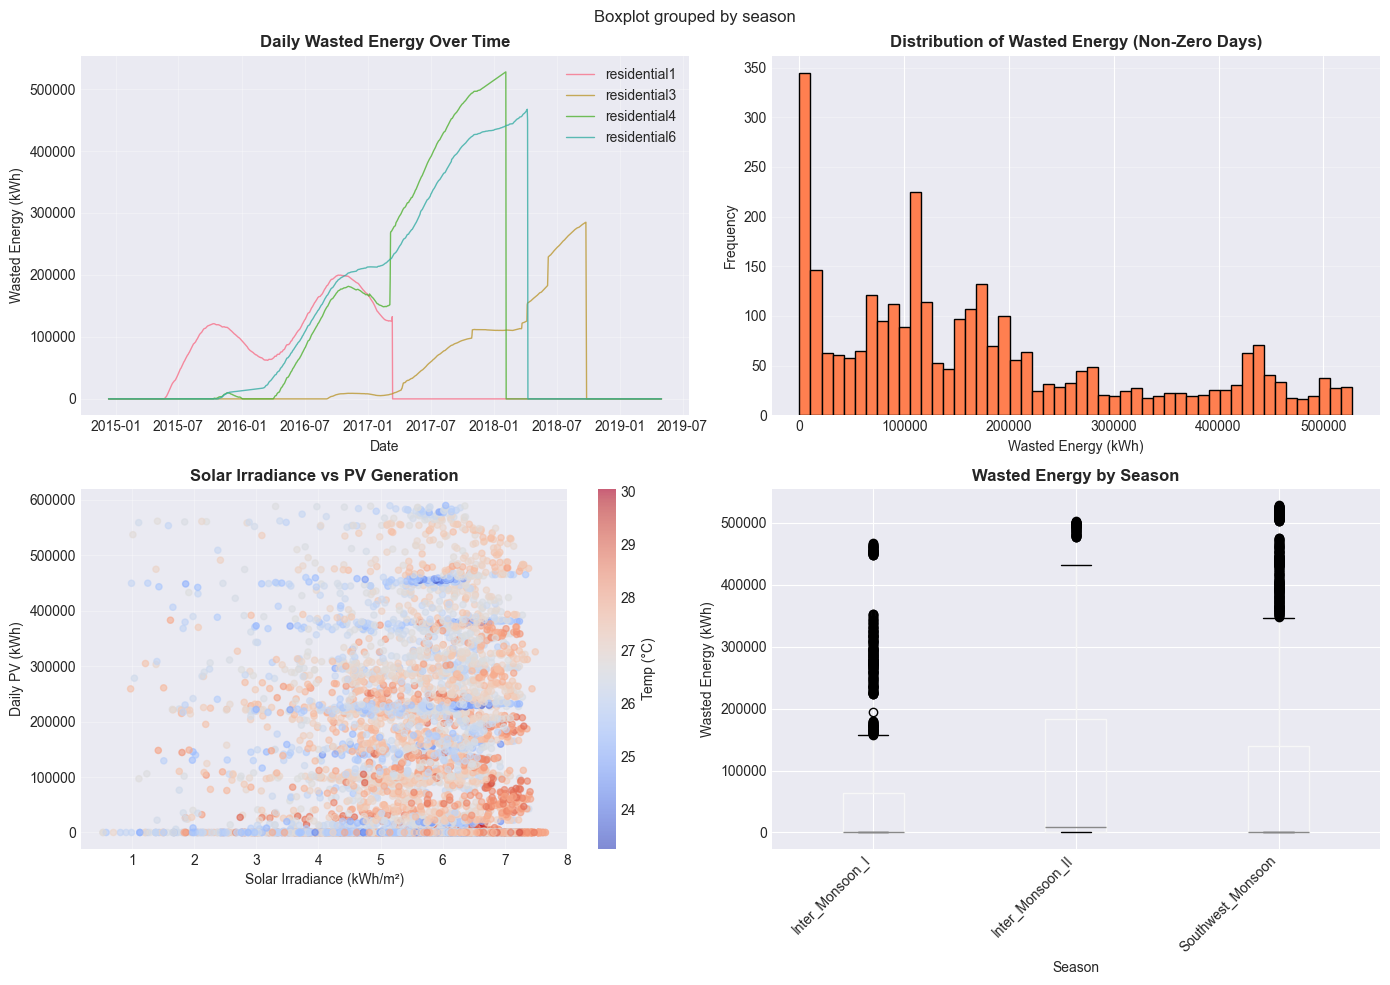

In [39]:
# Visualize target variable distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Wastage time series by household
for household in df['household'].unique():
    data = df[df['household'] == household].sort_values('date')
    axes[0, 0].plot(data['date'], data['wasted_energy_kwh'], label=household, linewidth=1, alpha=0.8)

axes[0, 0].set_title('Daily Wasted Energy Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Wasted Energy (kWh)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribution of wastage
axes[0, 1].hist(df[df['wasted_energy_kwh'] > 0]['wasted_energy_kwh'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution of Wasted Energy (Non-Zero Days)', fontweight='bold')
axes[0, 1].set_xlabel('Wasted Energy (kWh)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Weather data relationship
scatter = axes[1, 0].scatter(df['irradiance'], df['daily_pv_kwh'], 
                             c=df['temp'], cmap='coolwarm', alpha=0.6, s=20)
axes[1, 0].set_title('Solar Irradiance vs PV Generation', fontweight='bold')
axes[1, 0].set_xlabel('Solar Irradiance (kWh/m²)')
axes[1, 0].set_ylabel('Daily PV (kWh)')
plt.colorbar(scatter, ax=axes[1, 0], label='Temp (°C)')
axes[1, 0].grid(True, alpha=0.3)

# Wastage by season
df.boxplot(column='wasted_energy_kwh', by='season', ax=axes[1, 1])
axes[1, 1].set_title('Wasted Energy by Season', fontweight='bold')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Wasted Energy (kWh)')
plt.sca(axes[1, 1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 11. Save Processed Dataset

In [41]:
# Save the processed dataset
output_path = Path('../data/processed/features_engineered1.csv')
df.to_csv(output_path, index=False)

print(f"✓ Processed dataset saved to: {output_path}")
print(f"  File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")
print(f"  Rows: {len(df)}")
print(f"  Columns: {len(df.columns)}")

# Save feature list for reference
feature_list_path = Path('../data/processed/feature_list.txt')
with open(feature_list_path, 'w') as f:
    f.write("=== FEATURE ENGINEERING SUMMARY ===\n\n")
    f.write(f"Target Variable:\n")
    f.write(f"  - wasted_energy_kwh\n\n")
    
    f.write(f"Features:\n")
    for col in sorted(df.columns):
        if col not in ['date', 'household', 'district', 'wasted_energy_kwh']:
            f.write(f"  - {col}\n")

print(f"✓ Feature list saved to: {feature_list_path}")

print(f"\n=== READY FOR ML MODELS ===")
print(f"Next steps:")
print(f"  1. Create 03_model_training.ipynb for model development")
print(f"  2. Split into train/test sets")
print(f"  3. Scale features")
print(f"  4. Train multiple regression models")
print(f"  5. Evaluate and compare")

✓ Processed dataset saved to: ..\data\processed\features_engineered1.csv
  File size: 2.27 MB
  Rows: 6412
  Columns: 43
✓ Feature list saved to: ..\data\processed\feature_list.txt

=== READY FOR ML MODELS ===
Next steps:
  1. Create 03_model_training.ipynb for model development
  2. Split into train/test sets
  3. Scale features
  4. Train multiple regression models
  5. Evaluate and compare


In [27]:
# Display dataset statistics
print("\n=== DATASET STATISTICS ===")
print(f"\nShape: {df.shape}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nTarget variable (wasted_energy_kwh):")
print(df['wasted_energy_kwh'].describe())
print(f"\nNumerical features summary:")
print(df.describe().T[['mean', 'std', 'min', 'max']].round(2))


=== DATASET STATISTICS ===

Shape: (6412, 43)

Data types:
float64           31
int32              6
object             3
datetime64[ns]     1
UInt32             1
int64              1
Name: count, dtype: int64

Target variable (wasted_energy_kwh):
count     6412.000000
mean       171.446201
std       1405.894458
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      23435.077800
Name: wasted_energy_kwh, dtype: float64

Numerical features summary:
                                         mean            std  \
date                      2017-02-19 00:00:00            NaN   
daily_pv_kwh                    117407.728907    156027.6952   
daily_load_kwh                    36970.41316   50440.374898   
net_export                       80437.315747  135412.315289   
wasted_energy_kwh                  171.446201    1405.894458   
export_limit_kwh                  356283.6908   127149.30171   
year                              2016.655646       1.291